In [1]:
import random
import ast
import inspect
import instructor
import json

import openai

from pydantic import BaseModel, Field
from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from operator import add

from IPython.display import Image, display

from qdrant_client import QdrantClient
from qdrant_client.models import (
    Filter,
    FieldCondition,
    MatchValue,
    VectorParams,
    Distance,
    SparseVectorParams,
    Modifier,
    PayloadSchemaType,
    Document,
    PointStruct,
    Prefetch,
    FusionQuery,
    RrfQuery,
    Rrf
)

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send

from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, convert_to_openai_messages, convert_to_messages

from langsmith import traceable

from utils.utils import get_tool_descriptions, format_ai_message

/Users/vaidasarmonas/Learning/AI-Engineering-Bootcamp/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


## Query Expansion - Parallel Execution

In [29]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    question_relevant: bool = False
    answer: str = ""
    query: str = ""
    k: int = 10

### Query Expansion / Rewriting Node

In [30]:
QUERY_MULTI = "Can I get a kids book for my sone and a fiction book for me?"

In [31]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

@traceable(
    name="expand_query",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expansion_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a query expansion module in a shopping assitant. Your job is to rewrite a customers query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attirbute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get finction book for me and a kids book for my son?"
Statements:
- "Fiction book"
- "Kids book"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys"
Statements:
- "Toys"

<question>
{{ query }}
</question>
    """

    prompt = Template(prompt_template).render(query=state.initial_query)

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {
                "role": "system",
                "content": prompt
            }
        ],
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

In [32]:
def query_expand_conditional_edge(state: State) -> list:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )
    
    return send_messages


### Retriever Node

In [33]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model": "text_embedding_3_small"}
)
def get_embedding(text, model='text-embedding-3-small'):

    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding

@traceable(
    name="retriever_node",
    run_type='retriever'
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")
    query = state["query"]
   
    query_embedding = get_embedding(query)
    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25",
                ),
                using="bm25",
                limit=20
            )
        ],
        query=RrfQuery(rrf=Rrf(weights=[1,1])),
        limit=state["k"]
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []
    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""
    for id, chunck, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunck}\n"

    return {
        "retrieved_context": [formatted_context]
    }

### Agregator Node

In [34]:
class AggregatorResponse(BaseModel):
    answer: str

In [35]:
@traceable(
    name="aggregator",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returend with detailed specification in bullet points.

## Context:

{{ preprocessed_context }}

## Question:

{{ question }}
    """

    prompt = Template(prompt_template).render(
        preprocessed_context=state.retrieved_context,
        question=state.initial_query
        )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {
                "role": "system",
                "content": prompt
            }
        ],
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

### User Intent Router Node

In [36]:
class IntentRouterNode(BaseModel):
    question_relevant: bool
    answer: str

In [43]:
@traceable(
    name="intent_router",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a shopping assistant that answers question about products in stock.
You will be given a question and a list of context.

## Instructions

- Determine whether the question is about products, inventory or purchasing.
- Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
- Questions about store policies, personal advice, or unrelated topics are not relevant.
- If the questions is not relevant, add reason for it in the "answer" output field.

## Examples

Question: "Do you have running shoes under $100?"
Relevant: yes

Question: "What's the weather like today?"
Relevant: no - not related to products

Question: "Can you help me write an essay?"
Relevant: no - not relevant to products

Question: "Which laptop has the best battery life?"
Relevant: yes

Question: "What's your return policy?"
Relevant no - about store policy, not product information

<question>
{{ question }}
</question>
    """

    prompt = Template(prompt_template).render(
        question=state.initial_query
        )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {
                "role": "system",
                "content": prompt
            }
        ],
        response_model=IntentRouterNode
    )

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [49]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "query_expansion_node"
    
    return "end"

In [50]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_conditional_edges("query_expansion_node", query_expand_conditional_edge)
workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "query_expansion_node": "query_expansion_node",
        "end": END
    }
    )

workflow.add_edge(START, "intent_router_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

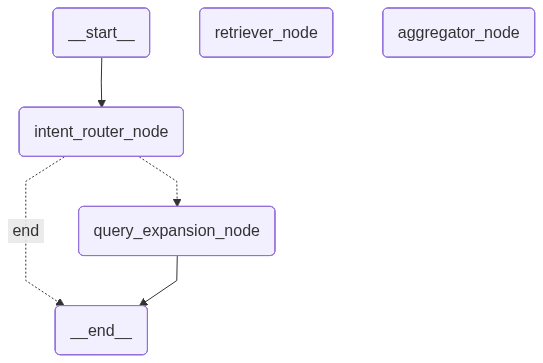

In [51]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
initial_state = {
    "initial_query": QUERY_MULTI
}

In [53]:
result = graph.invoke(initial_state)
result

{'expanded_query': ['Kids book', 'Fiction book'],
 'retrieved_context': ['- ID: B09TF1PB7G, rating: 4.0, description: Easter Basket Stuffers: I Spy Easter Book for Kids: Coloring Book for Toddlers and Preschoolers: Easter Activity Books For Kids ★ Great Easter Basket Stuffers For 2022★ - SPECIAL LAUNCH PRICE (WHILE STOCKS LAST!!!! ) Preschoolers and toddlers will have tons of fun with our I Spy Easter Activity Book! If you are looking for an interactive I Spy book for kids ages 2-5 then this fun activity book is perfect for you. ★You will find great Easter patterns that will catch a kids attention while learning.★ Perfect books for 2+. Perfectly Sized for little hands ♥This one has Easter theme and is full of amazing designs! ♥ Over 100 pages of fun! With over 100 cartoon graphics for kids featuring bunny, eggs, chicken, Angel, Bible, etcThis Easter activity book for toddlers and Preschool will definitely to keep your little learner engaged. Perfect present for kids, girls, boys, teens

In [54]:
print(result["answer"])

For your son, there are several wonderful kids' books available:

1. "Easter Basket Stuffers: I Spy Easter Book for Kids" - An interactive Easter activity book for toddlers and preschoolers ages 2-5 with over 100 pages of fun including bunny, eggs, chicken, Angel, Bible themed graphics. Perfectly sized for little hands.

2. "Merry Christmas Coloring Book for Kids" - A Christmas-themed coloring book for children ages 4-8 with 30 fun and festive designs, marker-safe pages, and a glossy premium cover.

3. "The Ultimate Space Coloring Book For Kids" - Features 50 space-themed line drawings including planets, rockets, astronauts, and aliens. Suitable for ages 3-8, with single-sided pages to prevent bleed-through.

4. "Easter Mazes for Kids Ages 6+" - A maze activity book with more than 140 mazes in various shapes, designed to improve concentration and cognitive skills for kids age 6 and older.

5. "Easter Coloring Book for Kids: Gnomes and Bunnies" - Contains intricate Easter-themed colorin

In [55]:
IRRELEVANT_QUERY = "What is the weather?"

In [56]:
initial_state = {
    "initial_query": IRRELEVANT_QUERY
}

In [57]:
result = graph.invoke(initial_state)
print(result["answer"])

The question is asking about the weather, which is not related to products, inventory, or purchasing.
